In [25]:
import numpy as np
import pywt
import matplotlib.pyplot as plt
from PIL import Image
import copy

In [26]:
def extend_signal(signal, mode):

    if mode == 'symmetric':
        signal = np.concatenate((signal, signal[::-1]), axis=0)
    elif mode == 'periodic':
        signal = np.concatenate((signal, signal), axis=0)
    elif mode == 'zero':
        pass
    else:
        raise ValueError('Invalid mode')
    
    return signal

In [27]:
def get_universal_threshold(first_details, N):
    '''
    Obtiene el umbral universal a partir de una estimación
    del nivel de ruido de la señal.
    :param first_details: Detalles de la primera descomposición
    :param N: Número de muestras de la señal
    :return: Umbral universal
    '''

    #mad(h1)/0.6745
    median = np.median(first_details)
    mad = np.median(np.abs(first_details - median))

    scaling_factor = 0.6751
    stimate = mad / scaling_factor

    threshold = stimate * np.sqrt(2 * np.log(N))
    return threshold

In [28]:
def hard_threshold(details, threshold):
        return np.where(np.abs(details) < threshold, 0, details)

def soft_threshold(details, threshold):
        return np.sign(details) * np.where(np.abs(details) < threshold, 0, np.abs(details) - threshold)

def apply_threshold(details, threshold, mode='hard'):
    '''
    Aplica el umbral a los detalles de una descomposición.
    :param details: Detalles de la descomposición [d1, d2, ..] con d_i una lista
    :param threshold: Umbral
    :param mode: Modo de umbralización (hard, soft)
    :return: Detalles umbralizados
    '''
    if mode == 'hard':
        return [hard_threshold(detail, threshold) for detail in details]
    
    if mode == 'soft':
        return [soft_threshold(detail, threshold) for detail in details]


In [29]:
def get_highpass_filter(low_pass_filter):
    '''
    Obtiene el filtro paso alto a partir del filtro pasa bajas.
    :param low_pass_filter: Filtro pasa bajas
    :return: Filtro paso alto
    '''
    high_pass = np.copy(low_pass_filter)
    high_pass = np.flip(high_pass)
    high_pass[::2] *= -1
    return high_pass

In [30]:
def apply_deconstruction(signal, low_pass_filter, mode='zero'):

    signal = extend_signal(signal, mode)
    high_pass = get_highpass_filter(low_pass_filter)

    aprox = np.convolve(signal, low_pass_filter)
    details = np.convolve(signal, high_pass)

    return aprox[1::2], details[1::2]

In [49]:
def apply_construction(aprox, details, low_pass_filter):
    '''
    Obtiene la aproximación al nivel j de resolución a partir de la aproximación
    y los detalles del nivel j-1.
    :param aprox: Aproximación al nivel j-1 
    :param details: Detalles del nivel j-1
    :param low_pass_filter: Filtro pasa bajas
    :return: Aproximación al nivel j
    '''

    l = len(low_pass_filter)
    high_pass_filter = get_highpass_filter(low_pass_filter)

    _low  = np.flip(low_pass_filter)
    _high = np.flip(high_pass_filter)
    
    _aprox = np.zeros(len(aprox)*2)
    _aprox[::2] = aprox

    _details = np.zeros(len(details)*2)
    _details[::2] = details

    r1 = np.convolve(_aprox, _low) 
    r2 = np.convolve(_details, _high)
    
    if len(r1) > len(r2):
        r2 = np.pad(r2, (0, len(r1) - len(r2)), mode='constant')
   
    r = r1 + r2

    return r[l-2:-l+1]


In [32]:
def thresholding(deatails,N, threshold_value, threshold_mode):
    if threshold_mode == 'universal':
        threshold_value = get_universal_threshold(deatails[-1], N)
        threshold_mode = 'soft'
        
    return apply_threshold(deatails, mode = threshold_mode, threshold=threshold_value)



def dwt(signal, low_pass_filter, level=1, mode='zero', threshold_value=None, threshold_mode=None):
    ''' 
    Aplica la transformada de ondículas
    :param signal: Señal a descomponer
    :param low_pass_filter: Filtro pasa bajos
    :param level: Nivel de descomposición
    :param mode: Modo de extensión
    :param threshold: Umbral de truncamiento
    :return: Aproximación y detalles a1, [d1, d2, ..., dn]
    '''

    aprox = signal
    details = []
    for _ in range(level):
        aprox, detail = apply_deconstruction(aprox, low_pass_filter, mode)
        details.insert(0, detail)

    if threshold_mode:
        details = thresholding(details,len(signal), threshold_value, threshold_mode )
        
    return aprox, details

In [33]:
def idwt(aprox, details, low_pass_filter, level=None, mode='zero', length=None):
    ''' 
    Aplica la transformada inversa de ondículas
    :param aprox: Aproximación a1
    :param details: Detalles (d1, d2, ..., dn)
    :param low_pass_filter: Filtro de paso bajo
    :param level: Nivel de descomposición
    :return: Señal reconstruida
    '''

    if level is None:
        level = len(details)
    
    signal = aprox
    for detail in details:
        signal = apply_construction(signal, detail, low_pass_filter)

   
    if length:
        signal = signal[:length]

    return signal

In [53]:
def denoise(signal, low_pass_filter, level=1, mode='zero'):
    '''
    Aplica la transformada de ondículas y elimina el ruido
    utilizando el umbral universal.
    :param signal: Señal a descomponer
    :param low_pass_filter: Filtro paso bajo
    :param level: Nivel de descomposición
    :param mode: Modo de extensión
    :return: Señal denoised
    '''
    aprox, details = dwt(signal, low_pass_filter, level, mode, threshold_mode='universal')
    return idwt(aprox, details, low_pass_filter, level, mode, len(signal))

In [57]:
def apply_deconstruct_2d(image, low_pass_filter, mode='zero'):
    '''
    Aplica la transformada de ondículas a una matriz
    :param signal: Señal a descomponer (matriz)
    :param low_pass_filter: Filtro pasa bajos
    :param level: Nivel de descomposición
    :param mode: Modo de extensión de la señal
    :return: cA, cH, cV, cD
    '''
    
    coeffs_rows = []

    # Aplicamos dwt a las filas
    for row in image:
        cA_row, cD_row = apply_deconstruction(row, low_pass_filter, mode=mode)
        coeffs_rows.append(np.concatenate((cA_row, cD_row)))
        

    coeffs_rows = np.array(coeffs_rows)

    
    # Aplicamos dwt a las columnas (del resultado anterior)
    coeffs = []
    for col in coeffs_rows.T:
        cA_col, cD_col = apply_deconstruction(col, low_pass_filter, mode=mode)
        coeffs.append(np.concatenate((cA_col, cD_col)))

    coeffs = np.array(coeffs).T

    #dividimos la matriz en 4 partes
    #  cA | cH
    #  --------
    #  cV | cD
    
    cA = coeffs[:len(coeffs)//2, :len(coeffs)//2]
    cH = coeffs[:len(coeffs)//2, len(coeffs)//2:]
    cV = coeffs[len(coeffs)//2:, :len(coeffs)//2]
    cD = coeffs[len(coeffs)//2:, len(coeffs)//2:]

    return cA, cH, cV, cD
    
    

In [59]:
def dwt_2d(image, low_pass_filter, level=1, mode='zero'):
    ''' 
    Aplica la transformada de ondículas a una matriz
    :param signal: Señal a descomponer (matriz)
    :param low_pass_filter: Filtro pasa bajos
    :param level: Nivel de descomposición
    :param mode: Modo de extensión de la señal
    :return: Aproximación y detalles cA, [detail1, detail2, ..., detailn] 
    siendo detail_i = [cHi, cVi, cDi]
    '''


    details = []

    for _ in range(level):
        cA, cH, cV, cD = apply_deconstruct_2d(image, low_pass_filter, mode=mode)
        image = cA
        details.insert(0, [cH, cV, cD])
    


    return cA, details
    

In [60]:
def join_aprox_and_details(aprox, details, casting=False, padding=True):
    '''
    Une la aproximación y los detalles de la descomposición para su presentación
    NO ES UNA RECONSTUCCIÓN
    :param aprox: Aproximación cA
    :param details: lista de detalles [d1,d2,..dn] con d_i=[cH_i, cV_i, cD_i]
    :param casting: realiza casting a uint8
    :param padding: si es True realiza padding de las submatrices menores. 
    En caso contrario, recorta la matriz mayor.
    :return: matrix de coeficientes y detalles
    '''

    n = len(details)

    for i in range(n):
        [cH, cV, cD] = details[i]

        if padding:
        # pad with zeros
            cH = np.pad(cH, (0, len(aprox) - len(cH)), mode='constant')
            cV = np.pad(cV, (0, len(aprox) - len(cV)), mode='constant')
            cD = np.pad(cD, (0, len(aprox) - len(cD)), mode='constant')
        else:
        #recortar matriz de detalles
            n = cH.shape[0]
            aprox = aprox[:n, :n]
        
        aprox = np.concatenate((np.concatenate((aprox, cH), axis=1), np.concatenate((cV, cD), axis=1)), axis=0)
    if casting:
        aprox = aprox.astype(np.uint8)
    return aprox

In [62]:
def idwt_2d(aprox, details, low_pass_filter, level=None, mode='zero', size=None):
    ''' 
    Aplica la transformada inversa de ondículas a una matriz
    :param aprox: Aproximación cA
    :param details: lista de detalles [d1,d2,..dn] con d_i=[cH_i, cV_i, cD_i]
    :param level: Nivel de descomposición
    :param mode: Modo de extensión de la señal
    :return: imagen reconstruida
    '''
    if level is None:
        level = len(details)

    for _ in range(level):
        [cH, cV, cD] = details.pop(0)
        aprox = join_aprox_and_details(aprox, [[cH, cV, cD]])
        col_aprox = []
        row_aprox = []

        #reconstruir las columnas
        for col in aprox.T:
            cA_col = col[:len(col)//2]
            cD_col = col[len(col)//2:]
            _col = apply_construction(cA_col, cD_col, low_pass_filter)
            col_aprox.append(_col)
        col_aprox = np.array(col_aprox).T
        

        for row in col_aprox:
            cA_row = row[:len(row)//2]
            cD_row = row[len(row)//2:]
            _row = apply_construction(cA_row, cD_row, low_pass_filter)
            row_aprox.append(_row)
        row_aprox = np.array(row_aprox)
            
        aprox = row_aprox
    
    if size:
        aprox = aprox[:size,:size]

    return aprox
    
    

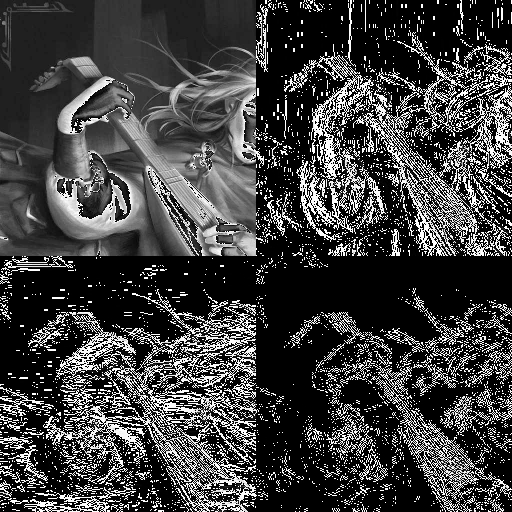

In [63]:
original_img = Image.open('kvothe.jpg').convert('L')
original_image_array = np.array(original_img)
low_pass_filter = np.array(pywt.Wavelet('db1').dec_lo)

# reshape original image_array to 512*512
original_image_array = original_image_array[:512,:512]
aprox, details = dwt_2d(original_image_array, low_pass_filter, level=1, mode='zero')


matrix = join_aprox_and_details(copy.deepcopy(aprox), copy.deepcopy(details), casting=True)
img = Image.fromarray(matrix)
display(img)

0


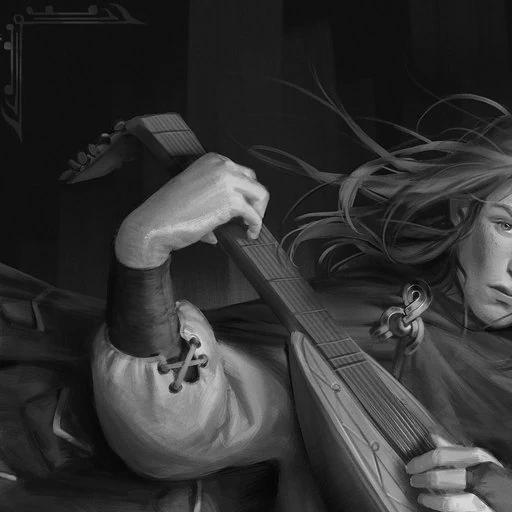

In [64]:
rec = idwt_2d(aprox, details, low_pass_filter, mode='zero', size=512)
rec = np.round(rec).astype(np.uint8)
print(np.count_nonzero(rec-original_image_array))
img = Image.fromarray(rec)
display(img)

In [69]:
def cut_details(details, value):
    '''
    Convierte a cero todos los detalles cuyo valor absoluto sea menor que el percentil
    :param details: lista de detalles [d1,d2,..dn] con d_i=[cH_i, cV_i, cD_i]
    :param value: valor del percentil (en tanto por ciento)
    '''
    
    total = np.concatenate([np.ravel(subdetail) for sublist in details for subdetail in sublist])
    
    percentile = np.percentile(np.abs(total), value)
    
   
    for sublist in details:
        for subdetail in sublist:
            subdetail[np.abs(subdetail) < percentile] = 0



In [ ]:
def compress(image, low_pass_filter, level=1, mode='zero',percentage=0.8):
    aprox, details = dwt_2d(image, low_pass_filter, level, mode)
 
    hist = []
    for detail in details:
        for subdetail in detail:
            #add the histogram to an existing one
            hist, _ = np.histogram(subdetail)
    
    print(hist)
    
    #return idwt_2d(aprox, details, low_pass_filter, level, mode)

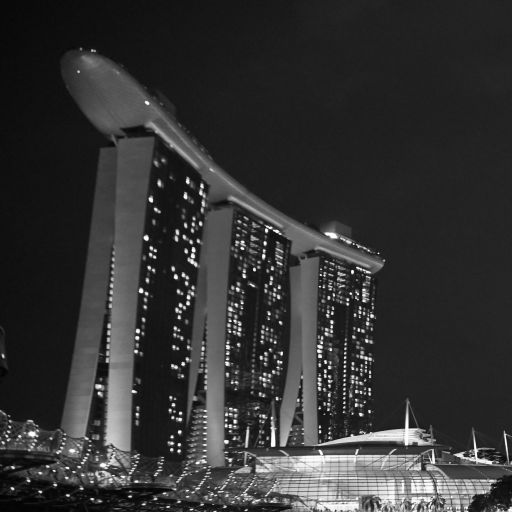

In [ ]:
original_img = Image.open('s2.jpg').convert('L')
original_image_array = np.array(original_img)
original_image_array = original_image_array[:512,:512]
img =Image.fromarray(original_image_array)
img.save('s2_gray.jpg')
display(img)

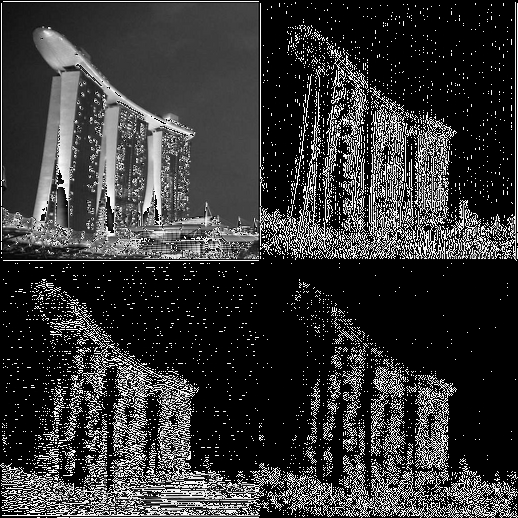

In [ ]:
low_pass_filter = np.array(pywt.Wavelet('db4').dec_lo)

# reshape original image_array to 512*512
original_image_array = original_image_array[:512,:512]
aprox, details = dwt_2d(original_image_array, low_pass_filter, level=1, mode='zero')


matrix = join_aprox_and_details(copy.deepcopy(aprox), copy.deepcopy(details), casting=True, padding=True)
img = Image.fromarray(matrix)
img.save('1level.jpeg')

display(img)

210362


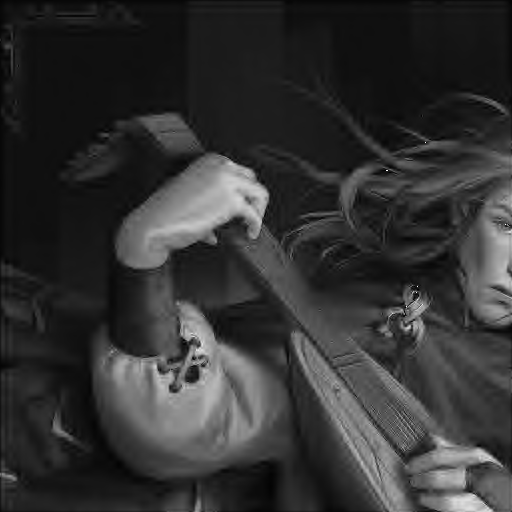

In [ ]:
original_image_array = original_image_array[:512,:512]
aprox, details = dwt_2d(original_image_array, low_pass_filter, level=3, mode='zero')
cut_details(details, 99)
rec = idwt_2d(aprox, details, low_pass_filter, mode='zero', size=512)
rec = np.round(rec).astype(np.uint8)
print(np.count_nonzero(rec-original_image_array))
img = Image.fromarray(rec)
img.save('compressed90.jpeg')
display(img)

In [ ]:
# (1/2^{2*level})+(1-0.8)(3/2^{2*level}) 

In [ ]:
def compression_rate(level, percentile):
    return (1/4)**(level) + (1-(1/4)**(level))*(1-percentile)

compression_rate(4, 0.9)

0.10351562499999997

(133, 133) (133, 133)


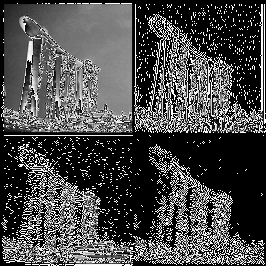

In [ ]:

aprox, details = dwt_2d(aprox, low_pass_filter, level=1, mode='zero')
print(aprox.shape, details[0][0].shape)

matrix = join_aprox_and_details(copy.deepcopy(aprox), copy.deepcopy(details), casting=True, padding=False)
img = Image.fromarray(matrix)
display(img)

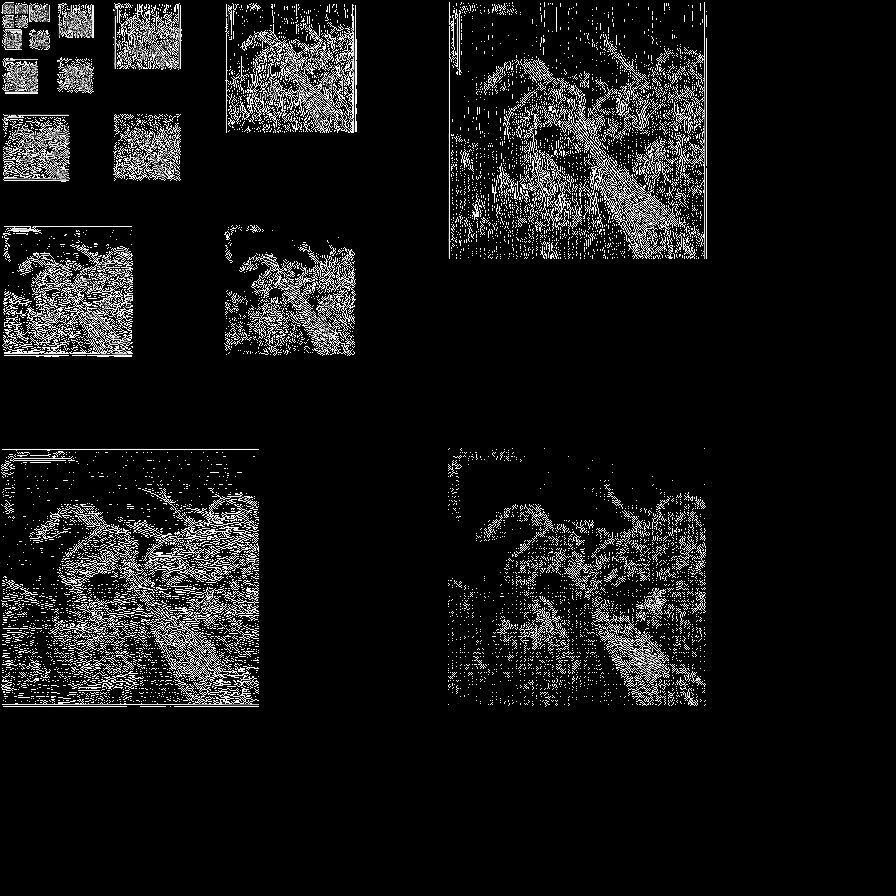

In [ ]:
original_img = Image.open('kvothe.jpg').convert('L')
original_image_array = np.array(original_img)
low_pass_filter = np.array(pywt.Wavelet('db4').dec_lo)

# reshape original image_array to 512*512
original_image_array = original_image_array[:512,:512]
aprox, details = dwt_2d(original_image_array, low_pass_filter, level=6, mode='zero')


matrix = join_aprox_and_details(copy.deepcopy(aprox), copy.deepcopy(details), casting=True)
img = Image.fromarray(matrix)
display(img)

In [ ]:
cut_details(details, 99)

235325


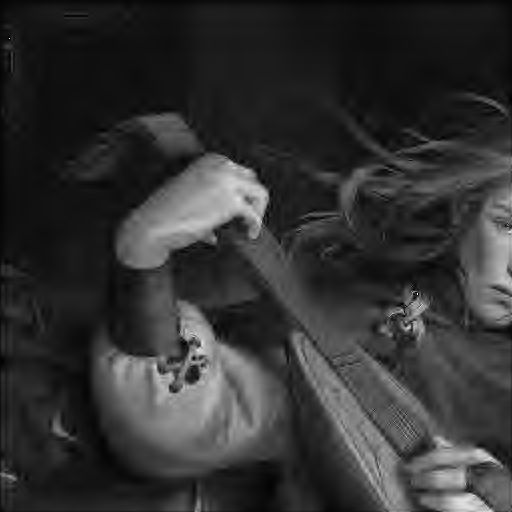

In [ ]:
rec = idwt_2d(aprox, details, low_pass_filter, mode='zero', size=512)
rec = np.round(rec).astype(np.uint8)
print(np.count_nonzero(rec-original_image_array))
img = Image.fromarray(rec)
display(img)

In [ ]:
total = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
percentile = np.percentile(total, 90)
print(percentile)

13.6
